In [ ]:
from data import DataLoader
from config import ExperimentConfig
from features import FeatureExtractor

config: ExperimentConfig = ExperimentConfig(data_dir="UCMerced_LandUse",classifier_type="svm",vocab_size=100,svm_kernel="rbf",svm_C=1.0,use_feature_scaling=True)
data_loader = DataLoader(config)




images, labels, class_names = data_loader.load_images_and_labels()
feature_extractor = FeatureExtractor(config)
features = feature_extractor.deep_nn_feature_extraction(images)
print(f"Extracted features shape: {features.shape}")



Loading images from: UCMerced_LandUse
Found classes: ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']
Loaded 2100 images from 21 classes


/home/ayoub/miniconda3/envs/develop/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ayoub/miniconda3/envs/develop/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  Processed 100/2100 images
  Processed 200/2100 images
  Processed 300/2100 images
  Processed 400/2100 images
  Processed 500/2100 images
  Processed 600/2100 images
  Processed 700/2100 images
  Processed 800/2100 images
  Processed 900/2100 images
  Processed 1000/2100 images
  Processed 1100/2100 images
  Processed 1200/2100 images
  Processed 1300/2100 images
  Processed 1400/2100 images
  Processed 1500/2100 images
  Processed 1600/2100 images
  Processed 1700/2100 images
  Processed 1800/2100 images
  Processed 1900/2100 images
  Processed 2000/2100 images
  Processed 2100/2100 images
Extracted deep features shape: (2100, 512)
Extracted features shape: (2100, 512)


In [3]:
# import train_test_split
from sklearn.model_selection import train_test_split
# import svm and metrics
from sklearn import svm
from sklearn import metrics
import numpy as np
from typing import List, Tuple
from matplotlib import pyplot as plt
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples") 
clf = svm.SVC(kernel=config.svm_kernel, C=config.svm_C)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
accuracy = metrics.accuracy_score(y_test, y_pred)
f1_score = metrics.f1_score(y_test, y_pred, average='weighted')
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test F1 Score: {f1_score:.4f}")


Training set size: 1680 samples
Test set size: 420 samples
Test Accuracy: 0.9143
Test F1 Score: 0.9128


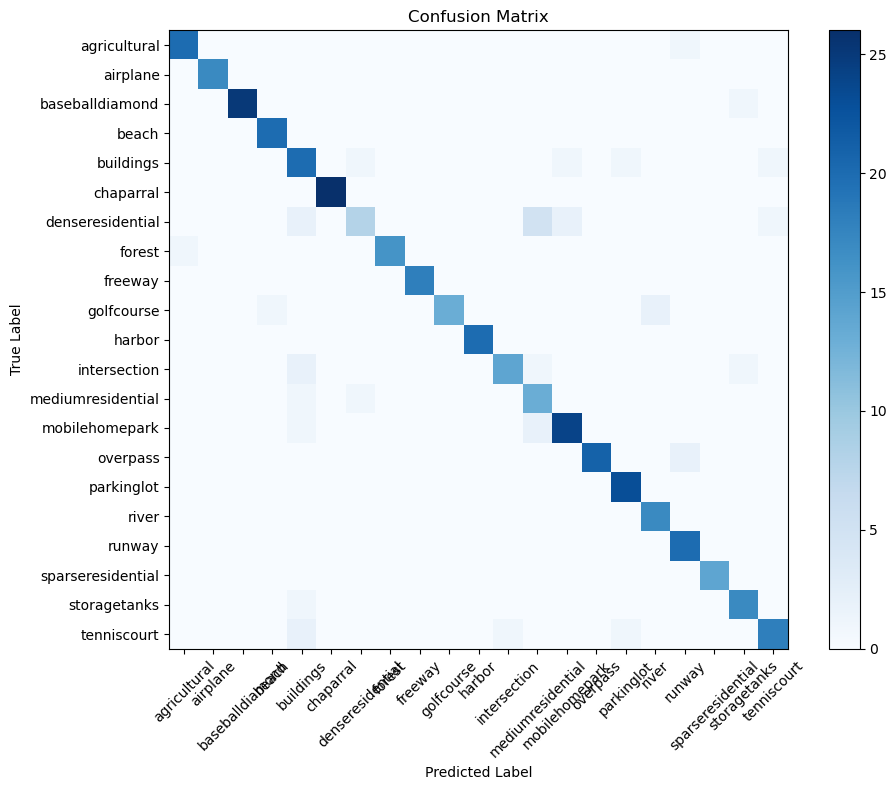

In [4]:
# plot confusion matrix
conf_matrix = metrics.confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

TypeError: ExperimentConfig.__init__() got an unexpected keyword argument 'dsc_method'